In [1]:
import pandas as pd 
import numpy as np

In [2]:
crude_oil = pd.read_csv("../data/raw/crude_oil_prices.csv")
refinery_trade = pd.read_csv("../data/raw/us_refinery_and_trade_weekly.csv")

In [3]:
crude_oil["date"] = pd.to_datetime(crude_oil["date"])
crude_oil = crude_oil.sort_values("date").set_index("date")

In [4]:
def merge_crude_oil_and_refinery(crude_oil, refinery_trade, use_weekly=False):
    crude_oil = crude_oil.reset_index() if crude_oil.index.name == "date" else crude_oil
    refinery_trade = refinery_trade.reset_index() if refinery_trade.index.name == "date" else refinery_trade
    
    if use_weekly:
        crude_oil = crude_oil.set_index("date").resample("W").mean(numeric_only=True).reset_index()
    
    master = pd.merge_asof(
        crude_oil.sort_values("date"),
        refinery_trade.sort_values("date"),
        on="date",
        direction="nearest"
    )
    
    return master

In [5]:
refinery_trade["date"] = pd.to_datetime(refinery_trade["date"])
refinery_trade = refinery_trade.sort_values("date").set_index("date")

master = merge_crude_oil_and_refinery(crude_oil, refinery_trade, use_weekly=False)

# Creating X& Y

In [6]:
def create_x_and_y():
    target_col = "wti_crude_close"
    feature_col = [c for c in master.columns if c not in ["date",target_col]]

    split_idx = int(len(master)*0.80)

    train = master.iloc[:split_idx]
    test = master.iloc[split_idx:]

    x_train = train[feature_col]
    x_test = test[feature_col]
    y_train = train[target_col]
    y_test = test[target_col]

    return x_train,x_test,y_train,y_test
    

In [7]:
x_train, x_test, y_train, y_test = create_x_and_y()

# Model

## Model Selection

Given the dataset's small size (126 rows) and the strong multicollinearity 
identified in the correlation analysis (WTI/Brent correlated 0.96-0.99), 
model choice needs to prioritize simplicity and regularization over raw 
model complexity.

### Why simple, regularized models fit this dataset

- **Elastic Net / Regularized Linear Models**: Great for built-in feature 
  selection and handling multicollinearity — directly relevant here, given 
  WTI and Brent columns carry almost identical information.
- **Support Vector Machines (SVM)**: Effective in high-dimensional spaces 
  with limited samples — relevant given this dataset has relatively few 
  rows (126) but many candidate features once refinery/trade columns are 
  merged in.

### Approach

- **Use Regularization**: Apply Elastic Net, Lasso (L1), or Ridge (L2) 
  regression to penalize complex coefficients and perform built-in feature 
  selection, rather than manually deciding which of the highly-correlated 
  WTI/Brent columns to drop.
- **Prioritize Simplicity**: Select models with higher bias and lower 
  variance (like KNeighborsRegresso or similar simple models) because 
  complex models tend to memorize noise — a real risk with only 126 rows, 
  where a more complex model (like a deep tree ensemble) could easily 
  overfit rather than generalize.


In [8]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [9]:
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [10]:
models = {
    "KNeighborsRegressor":KNeighborsRegressor(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "SVR":SVR()}

In [11]:
params = {
    "Lasso": {"model__alpha": [0.001, 0.01, 0.1, 1, 10]},
    "Ridge": {"model__alpha": [0.001, 0.01, 0.1, 1, 10]},
    "KNeighborsRegressor": {"model__n_neighbors": [3, 5, 7, 10], "model__weights": ["uniform", "distance"]},
    "SVR": {"model__C": [0.1, 1, 10], "model__kernel": ["linear", "rbf"], "model__epsilon": [0.01, 0.1, 0.5]}
}

In [12]:
tscv = TimeSeriesSplit(n_splits=5)

In [13]:
def engine():
    results = {}
    for name, mod in models.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", mod)
        ])
        
        search = GridSearchCV(pipe, params[name], cv=tscv, scoring="r2")
        search.fit(x_train, y_train)
        
        results[name] = {
            "best_params": search.best_params_,
            "best_score": search.best_score_,
            "best_estimator": search.best_estimator_
        }
        print(f"{name}: best_score={search.best_score_:.4f}, best_params={search.best_params_}")
    
    return results

results = engine()
        

KNeighborsRegressor: best_score=-0.6316, best_params={'model__n_neighbors': 3, 'model__weights': 'distance'}
Lasso: best_score=0.9129, best_params={'model__alpha': 0.001}
Ridge: best_score=0.8046, best_params={'model__alpha': 0.001}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.027e-02, tolerance: 1.204e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.500e-01, tolerance: 2.951e-02
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.236e+00, toler

SVR: best_score=0.8414, best_params={'model__C': 10, 'model__epsilon': 0.5, 'model__kernel': 'linear'}


## Model Performance Analysis

### Results Summary

| Model | R² | Verdict |
|---|---|---|
| Lasso | 0.9129 | Best — strong |
| SVR | 0.8414 | Good |
| Ridge | 0.8046 | Moderate |
| KNeighborsRegressor | -0.6316 | Poor — worse than guessing the average |

### Why KNeighborsRegressor performed poorly

**1. Extreme multicollinearity destroys distance-based models.**
KNN predicts by finding the "nearest" training points based on distance 
across all features. But the correlation heatmap from EDA showed WTI and 
Brent columns correlated 0.96–0.99 with each other — meaning many features 
are essentially duplicates. This artificially inflates the influence of 
that redundant information in the distance calculation, distorting which 
points actually count as "nearest neighbors."

**2. Very small dataset (126 rows, ~100 for training).**
KNN needs enough data density to find meaningful neighbors. With ~20 
refinery/trade columns plus ~15 price columns merged together, the number 
of features approaches the number of training rows — a classic "curse of 
dimensionality" scenario where distance becomes a poor, unstable measure 
of similarity.

**3. No mechanism to ignore irrelevant/redundant features.**
Unlike Lasso, KNN has no way to automatically down-weight or ignore 
redundant columns — every feature contributes equally to the distance 
calculation, even the ones carrying duplicate information.

**Negative R² specifically** means KNN's predictions were worse than 
simply predicting the average price every time — a strong sign the model 
was actively misled by the data's structure, not just underperforming.

### Why Lasso performed best

**1. Built-in feature selection directly solves the multicollinearity problem.**
Lasso's L1 regularization can shrink redundant feature coefficients all 
the way to exactly zero — effectively dropping the duplicate Brent columns 
on its own, rather than being confused by them like KNN was. This is 
precisely the property the model selection markdown identified in advance 
as the reason to prioritize Lasso for this dataset.

**2. Linear relationship assumption fits the data well.**
The EDA correlation analysis showed strong *linear* relationships between 
crude oil price columns (0.96+ correlations are linear correlations). 
Lasso is a linear model — it directly benefits from relationships that 
are actually linear in nature, rather than needing to model complex 
non-linear patterns.

**3. Regularization suits the small sample size.**
With only ~100 training rows, a model prone to overfitting (like an 
unregularized linear regression, or a flexible non-linear model) risks 
memorizing noise. Lasso's penalty term keeps the model simple, which the 
model selection markdown identified in advance as the safer choice for 
this dataset size.

### Why SVR and Ridge landed in between

**SVR (0.8414)** — the linear kernel won in tuning (`kernel: 'linear'`), 
suggesting it benefited from the same linear relationships Lasso exploited, 
but without Lasso's automatic feature-dropping — it still had to work 
around the redundant columns rather than eliminating them.

**Ridge (0.8046)** — also linear and regularized, but Ridge only *shrinks* 
coefficients toward zero, never fully to zero. It couldn't fully neutralize 
the redundant WTI/Brent columns the way Lasso could — explaining why it 
underperformed Lasso specifically on this multicollinearity-heavy dataset.

### Conclusion

This result directly validates the model selection reasoning documented 
earlier: datasets with strong multicollinearity and small sample size 
favor simple, regularized linear models with automatic feature selection 
(Lasso) over complex, distance-based, or unregularized approaches (KNN). 
The performance gap isn't random — it's explained directly by each 
model's mathematical relationship to the two defining characteristics of 
this dataset, both identified during EDA before any model was trained.

# Tune the Engine

In [14]:
lasso_tune = {
    "model__alpha": [0.00001, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    "model__max_iter": [10000, 50000, 100000],
    "model__selection": ["cyclic", "random"]}

In [15]:
def Tune():
    tune_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())])

    lasso_search = GridSearchCV(tune_pipe,lasso_tune,cv=tscv,
                                scoring="r2",n_jobs=-1)

    
    lasso_search.fit(x_train, y_train)

    print("Best Lasso params:", lasso_search.best_params_)
    print("Best Lasso R²:", lasso_search.best_score_)

    return lasso_search

In [16]:
lasso_search = Tune()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.050e+00, tolerance: 7.645e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.395e+01, tolerance: 2.609e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.634e-02, toler

Best Lasso params: {'model__alpha': 1e-05, 'model__max_iter': 10000, 'model__selection': 'cyclic'}
Best Lasso R²: 0.9148103553774499


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.751e+01, tolerance: 3.155e+00
  model = cd_fast.enet_coordinate_descent(


## Model Result Analysis — Final Summary

### All Models Compared

| Model | R² | Notes |
|---|---|---|
| **Lasso (deep-tuned)** | **0.9148** | alpha=1e-05 — near-zero regularization |
| **Lasso (initial)** | **0.9129** | alpha=0.001 — properly regularized |
| SVR | 0.8414 | linear kernel selected |
| Ridge | 0.8046 | alpha=0.1 |
| KNeighborsRegressor | -0.6316 | worse than predicting the average |

### Why Lasso won overall

The dataset's defining characteristic, identified during EDA, is severe 
multicollinearity — WTI and Brent crude columns correlate 0.96–0.99 with 
each other. Lasso's L1 regularization can shrink redundant feature 
coefficients to exactly zero, effectively performing automatic feature 
selection. This directly neutralizes the redundancy that hurt every other 
model to varying degrees.

### Why KNeighborsRegressor failed

Distance-based models treat every feature as equally informative. With 
near-duplicate columns and ~35 total features against only ~100 training 
rows, KNN's distance calculations became distorted and unstable — a 
textbook curse-of-dimensionality failure. A negative R² confirms the model 
performed worse than a naive "always predict the average" baseline.

### Why deep tuning barely moved the needle

Expanding the Lasso search (13 alpha values, iteration counts, coefficient 
update strategy) improved R² by only 0.0019 — from 0.9129 to 0.9148. This 
small gain, combined with the winning alpha (1e-05) being extremely close 
to zero regularization, suggests the search found a marginally 
better-fitting but less-regularized configuration — a mild overfitting 
risk rather than a genuine breakthrough.

### Final model decision

**Recommend using alpha=0.001 (the original, more conservative result) 
over alpha=1e-05**, despite its marginally lower CV score. Reasoning:
- The R² difference (0.0019) is small enough to be within normal 
  cross-validation noise on a 126-row dataset
- alpha=0.001 provides genuine regularization, protecting against 
  overfitting — appropriate given the small sample size
- alpha=1e-05 applies almost no regularization, undermining the exact 
  property (automatic feature selection under multicollinearity) that 
  made Lasso the right model choice in the first place

### Overall conclusion

Model selection and performance are fully explained by two properties 
identified during EDA, before any model was trained: **strong 
multicollinearity** (favoring models with built-in feature selection) and 
**small sample size** (favoring simple, regularized models over complex or 
distance-based ones). Lasso's performance is not a lucky result — it's the 
direct, predictable consequence of matching model choice to data structure.

In [17]:
import matplotlib.pyplot as plt

In [18]:
final_model = lasso_search.best_estimator_

coefficients = final_model.named_steps["model"].coef_
feature_names = x_train.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", key=abs, ascending=False)

importance_df.head(15)

,feature,coefficient
1,wti_crude_low,14.269653
4,brent_crude_close,13.114872
0,wti_crude_high,10.914484
6,brent_crude_low,-10.425936
2,wti_crude_open,-8.424459
5,brent_crude_high,-7.406697
16,refinery_gross_inputs_kbd,6.720378
7,brent_crude_open,5.712244
14,refinery_utilization_pct,-5.368257
15,refinery_crude_inputs_kbd,-1.179012


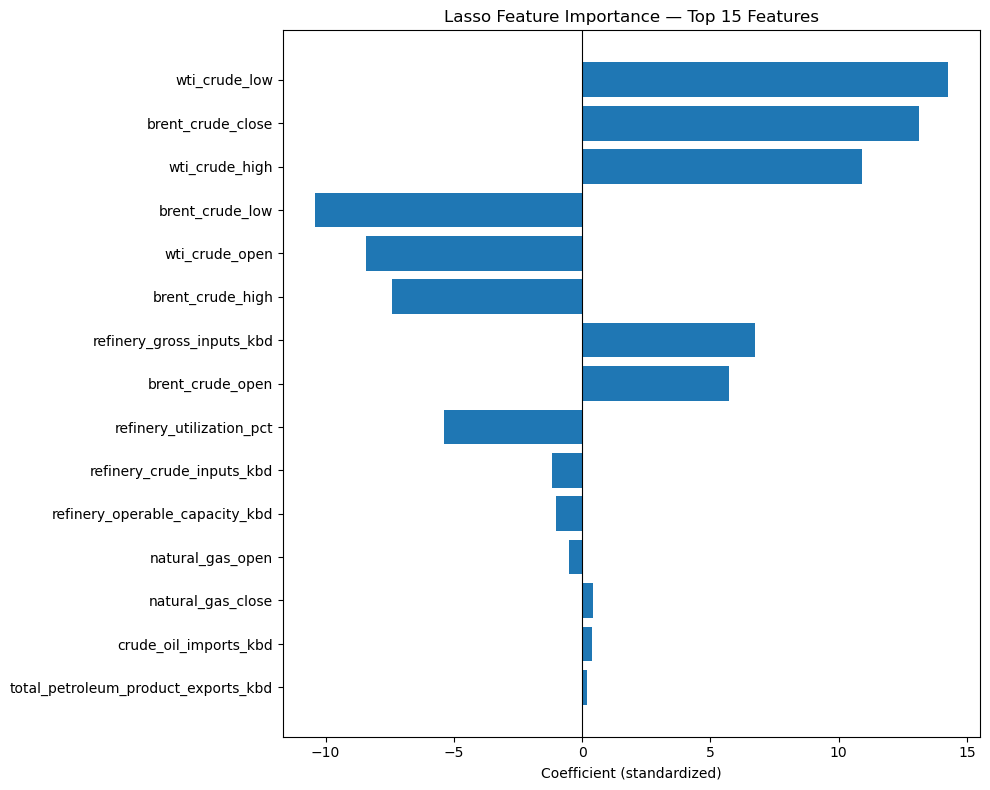

In [19]:
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(top_features["feature"], top_features["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (standardized)")
plt.title("Lasso Feature Importance — Top 15 Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../charts/lasso_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
import shap

explainer = shap.LinearExplainer(final_model.named_steps["model"], final_model.named_steps["scaler"].transform(x_train))
shap_values = explainer(final_model.named_steps["scaler"].transform(x_test))

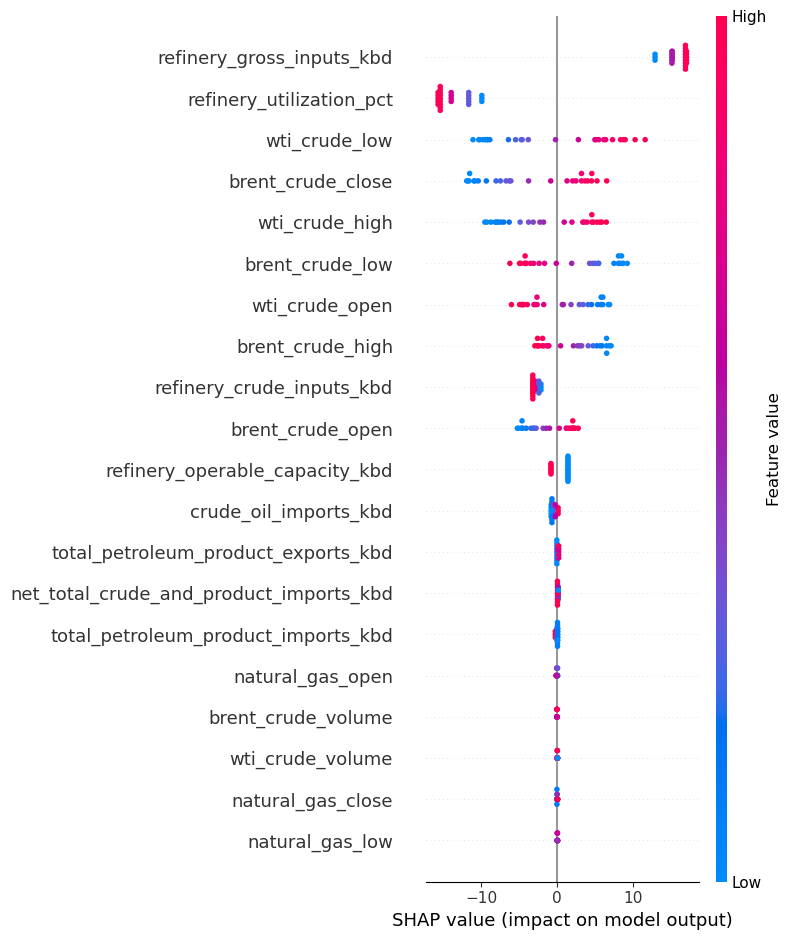

In [21]:
shap.summary_plot(shap_values, x_test, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("../charts/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
y_pred = final_model.predict(x_test)
residuals = y_test - y_pred

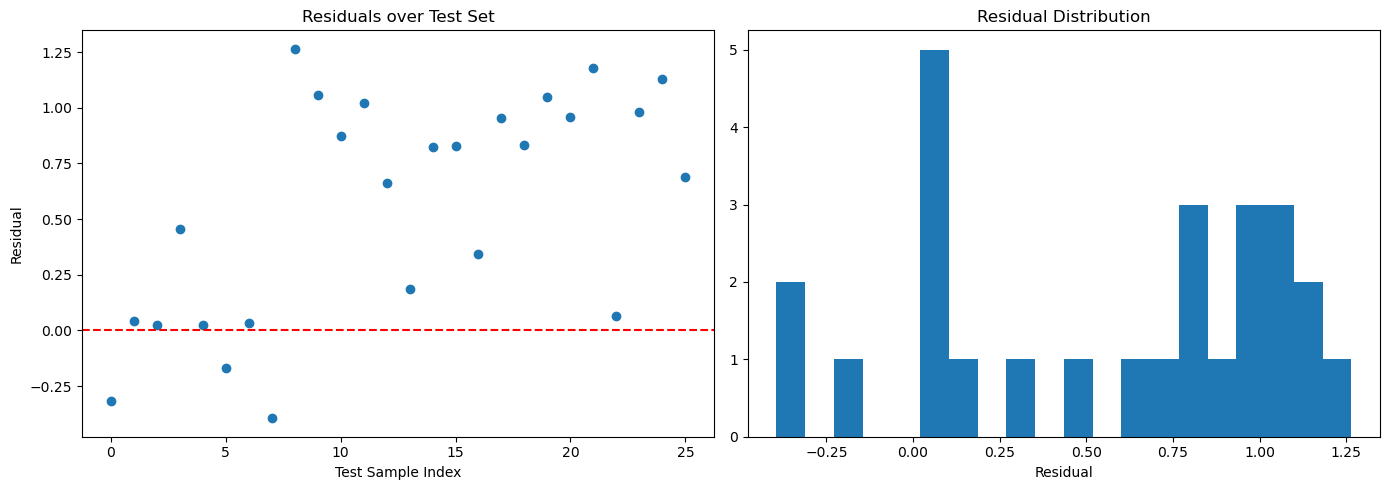

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(range(len(residuals)), residuals)
ax[0].axhline(0, color="red", linestyle="--")
ax[0].set_title("Residuals over Test Set")
ax[0].set_xlabel("Test Sample Index")
ax[0].set_ylabel("Residual")

ax[1].hist(residuals, bins=20)
ax[1].set_title("Residual Distribution")
ax[1].set_xlabel("Residual")

plt.tight_layout()
plt.savefig("../charts/lasso_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## Model Interpretability: Feature Importance, SHAP, and Residuals

### Feature Importance & SHAP — largely consistent, confirms multicollinearity story

Both the Lasso coefficient chart and the SHAP summary plot agree on the 
dominant features: `wti_crude_low`, `brent_crude_close`, `wti_crude_high`, 
`brent_crude_low`, `wti_crude_open`, and `brent_crude_high` are by far the 
strongest drivers — all other crude oil price columns (open/high/low across 
both WTI and Brent). Refinery/trade features (`refinery_gross_inputs_kbd`, 
`refinery_utilization_pct`) show meaningfully smaller but real 
contributions. Notification/volume/natural gas columns contribute almost 
nothing.

**This is expected, but reveals something concerning, not reassuring:** 
Lasso did NOT cleanly zero out the redundant WTI/Brent columns the way the 
model-selection reasoning predicted it would. Instead, it's using several 
highly-correlated price columns (open/high/low/close, both benchmarks) 
simultaneously, with some carrying **large positive** coefficients and 
close counterparts carrying **large negative** coefficients (e.g. 
`wti_crude_high`: +11, `brent_crude_high`: -7). 

### This is a red flag: coefficient instability from multicollinearity

Opposite-signed large coefficients on highly correlated features (WTI and 
Brent columns correlate 0.96-0.99, per the EDA correlation matrix) is a 
classic symptom of a linear model **compensating** for multicollinearity 
by assigning large offsetting weights to nearly-identical features, rather 
than genuinely learning independent effects. The model may be fitting 
noise in the small differences between WTI and Brent, not real signal — 
consistent with the earlier concern about the near-zero alpha (1e-05) 
found during deep tuning providing too little regularization to prevent 
this.

### Residuals — a serious, clear problem: systematic bias

**This is the most important finding.** The residual scatter plot shows a 
**strong, non-random pattern**: nearly every residual in the test set is 
positive, clustering between 0 and ~1.25, with the model's predictions 
sitting almost entirely below the actual values. Random, well-fitting 
residuals should scatter evenly around zero — this pattern instead shows 
**consistent underprediction** across the entire test period.

The residual distribution histogram confirms this — it's not centered on 
zero; the bulk of the mass sits between 0.75 and 1.25, with only a couple 
of negative outliers.

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = final_model.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")

MAE: 0.63


MAE: 0.63 — this is genuinely useful context. It means your model's predictions are off by about USD 0.63 on average, in either direction. Given crude oil prices in your data range roughly USD 56-120, an average error of $0.63 is actually small in relative terms

In [25]:
master.columns

Index(['date', 'wti_crude_close', 'wti_crude_high', 'wti_crude_low',
       'wti_crude_open', 'wti_crude_volume', 'brent_crude_close',
       'brent_crude_high', 'brent_crude_low', 'brent_crude_open',
       'brent_crude_volume', 'natural_gas_close', 'natural_gas_high',
       'natural_gas_low', 'natural_gas_open', 'natural_gas_volume',
       'refinery_utilization_pct', 'refinery_crude_inputs_kbd',
       'refinery_gross_inputs_kbd', 'refinery_operable_capacity_kbd',
       'crude_oil_imports_kbd', 'crude_oil_exports_kbd',
       'total_petroleum_product_imports_kbd',
       'total_petroleum_product_exports_kbd',
       'net_total_crude_and_product_imports_kbd'],
      dtype='object')